# Pandas & NumPy

## Introduction

Welcome! This notebook gives you a fast, hands-on tour of the two most important Python libraries for data science: **Pandas** and **NumPy**.

You do not need any prior experience with these libraries. All you need is basic Python — variables, lists, and loops.

By the end of this session, you will have run real code against real datasets and seen exactly what these tools can do.

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Import and use `pandas` and `numpy` correctly

2. Load a CSV file and explore its contents

3. Select, filter, and sort data from a DataFrame

4. Group data and compute summary statistics

5. Create new columns and handle missing values

6. Create basic plots directly from a DataFrame

7. Create and manipulate NumPy arrays

8. Work with dates and combine multiple DataFrames

---

## Part 1: Key Imports

Every data science script starts with **imports** — telling Python which external libraries to load.

- **`pandas`** — for tables of data (rows + columns), called DataFrames

- **`numpy`** — for fast numerical arrays and maths

- **`matplotlib.pyplot`** — for creating plots and charts

The `as` keyword gives a library a **short alias** so we don't have to type the full name every time.

> **Convention:** Always use `pd`, `np`, and `plt` as aliases — every data scientist in the world uses these same names.

> **Discussion:** Why do you think we use short aliases like `pd` instead of typing `pandas` every time?

In [2]:
# Import the three core libraries for data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Confirm versions — useful when debugging or sharing code
print('Pandas version :', pd.__version__)
print('NumPy version  :', np.__version__)

Pandas version : 3.0.1
NumPy version  : 2.4.3


---
## Part 2: Pandas — Loading & Exploring Data

### What is a DataFrame?

Think of a **DataFrame** as a spreadsheet inside Python — a table made of **rows** and **columns**. Each column has a name, and every row is one observation.

We load data from a CSV file using `pd.read_csv()`. That's it — one line.

> **Discussion:** What kinds of data do you work with in your day-to-day life that might look like a table?

In [ ]:
# Load the Iris dataset — a classic dataset about flower measurements
df = pd.read_csv('data/iris.csv') # there are also .read_excel() for Excel files, and .read_json() for JSON files

# Show the first 5 rows to get a feel for the data
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# --- Shape and column names ---
print('Rows, Columns:', df.shape)
print('Column names :', df.columns.tolist())

Rows, Columns: (150, 5)
Column names : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [5]:
# --- Quick data health check ---
# .info() shows column types and whether any values are missing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
# --- Summary statistics for all numeric columns ---
# .describe() gives count, mean, std, min, max, and quartiles
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Exploring Categorical Columns

The `species` column is **categorical** — it holds text labels, not numbers.

- `.unique()` — shows the distinct values

- `.value_counts()` — shows how many rows belong to each category

> **Discussion:** What does it tell you if one category has far more rows than others?

In [7]:
# --- Explore the categorical 'species' column ---

# How many unique species are there?
print('Unique species:', df['species'].unique())

# --- How many rows belong to each species? ---
print('\nCounts per species:')
print(df['species'].value_counts())

Unique species: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Counts per species:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


---

## Part 3: Selecting & Filtering Data

### Selecting Columns

Use square brackets `[]` to pick columns — just like looking up a **key** in a dictionary.

- `df['column_name']` → returns one column (this is a **Series**)

- `df[['col_1', 'col_2']]` → returns multiple columns (this is a **DataFrame**)

### Selecting Rows by Position — `.iloc[]`

**`iloc`** stands for *integer location*. Use it when you want rows by their position number (0, 1, 2 …)

### Selecting Rows by Label — `.loc[]`

**`loc`** selects by **label** — usually the index value or a condition.

> **Discussion:** When would you use `.iloc[]` vs `.loc[]`? Can you think of a real-world example for each?

In [15]:
# --- Select a single column ---
sepal_lengths = df['sepal_length']
print(type(sepal_lengths))
print(sepal_lengths.head())

<class 'pandas.Series'>
0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: sepal_length, dtype: float64


In [14]:
# --- Select multiple columns ---
measurements = df[['sepal_length', 'petal_length', 'species']]
print(type(measurements))
measurements.head()

<class 'pandas.DataFrame'>


,sepal_length,petal_length,species
0,5.1,1.4,Iris-setosa
1,4.9,1.4,Iris-setosa
2,4.7,1.3,Iris-setosa
3,4.6,1.5,Iris-setosa
4,5.0,1.4,Iris-setosa


In [ ]:
# --- iloc: select by position (row index number) ---
# Get rows index 0 to 4, all columns
df.iloc[0:5] # this is the same as calling df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
# --- loc: select by condition (boolean mask) ---
# Get all rows where species is 'setosa'
setosa_df = df.loc[df['species'] == 'Iris-setosa']
print('Setosa rows:', len(setosa_df))
setosa_df.head()

Setosa rows: 50


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Filtering with Multiple Conditions

Combine conditions with:

- `&` — AND (both must be true)

- `|` — OR (either can be true)

> **Important:** Each condition must be wrapped in `()` when combining.

> **Discussion:** How would you find all flowers with a sepal length above the average AND a petal length above 4?

In [22]:
# --- Filter: setosa species with sepal length > 5 ---
filtered = df[(df['species'] == 'Iris-setosa') & (df['sepal_length'] > 5)]
print('Rows matching filter =', len(filtered))
filtered.head()

Rows matching filter = 22


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
10,5.4,3.7,1.5,0.2,Iris-setosa
14,5.8,4.0,1.2,0.2,Iris-setosa
15,5.7,4.4,1.5,0.4,Iris-setosa


In [24]:
# --- Filter using .query() — a more readable alternative ---
# query() lets you write the condition as a plain-English string
result = df.query("species == 'Iris-setosa' and sepal_length > 5")
print('Rows matching query =', len(result))

Rows matching query = 22


---
## Part 4: Sorting & Grouping

### Sorting

`.sort_values('column')` arranges rows in ascending order by that column.

Add `ascending=False` to flip to descending order.

### Groupby — Split → Apply → Combine

This is one of the most powerful Pandas patterns:

1. **Split** the data into groups (e.g., by species)

2. **Apply** an operation to each group (e.g., calculate the mean)

3. **Combine** the results back into one table'

> **Discussion:** Can you think of a business question where you'd want to compare averages across groups? (e.g., sales by region, scores by class)

In [25]:
# --- Sort by petal_length, largest first ---
df.sort_values('petal_length', ascending=False).head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
118,7.7,2.6,6.9,2.3,Iris-virginica
122,7.7,2.8,6.7,2.0,Iris-virginica
117,7.7,3.8,6.7,2.2,Iris-virginica
105,7.6,3.0,6.6,2.1,Iris-virginica
131,7.9,3.8,6.4,2.0,Iris-virginica


In [26]:
# --- Groupby: average measurements per species ---
# Step 1: group rows by species
# Step 2: calculate the mean of each numeric column
species_means = df.groupby('species').mean()
species_means

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [28]:
# --- Groupby with a specific column and multiple aggregations ---
# .agg() lets you apply several functions at once
petal_stats = df.groupby('species')['petal_length'].agg(['mean', 'min', 'max'])
petal_stats

,mean,min,max
species,,,
Iris-setosa,1.464,1.0,1.9
Iris-versicolor,4.260,3.0,5.1
Iris-virginica,5.552,4.5,6.9


---
## Part 5: Column Operations & Handling Missing Data

### Creating New Columns

You can create a new column using arithmetic on existing columns. Pandas applies the operation **row by row** automatically — no loop needed.

### Renaming & Dropping Columns

- `.rename(columns={'old': 'new'})` — rename one or more columns

- `.drop(columns=['col'])` — remove a column

### Missing Values

Real-world data is messy. Missing values show up as `NaN` (Not a Number).

- `.isnull().sum()` — count missing values per column

- `.fillna(value)` — replace NaN with a given value

- `.dropna()` — remove rows that contain any NaN

> **Discussion:** If a column has 30% missing values, would you fill them or drop the rows? What factors would influence your decision?

In [29]:
# --- Create a new column: petal area (length × width) ---
df['petal_area'] = df['petal_length'] * df['petal_width']
df[['species', 'petal_length', 'petal_width', 'petal_area']].head()

,species,petal_length,petal_width,petal_area
0,Iris-setosa,1.4,0.2,0.28
1,Iris-setosa,1.4,0.2,0.28
2,Iris-setosa,1.3,0.2,0.26
3,Iris-setosa,1.5,0.2,0.30
4,Iris-setosa,1.4,0.2,0.28


In [30]:
# --- Check for missing values in the dataset ---
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
petal_area      0
dtype: int64


In [32]:
# --- Demonstrate fillna and dropna with an example ---

# Create a small DataFrame with some missing values
sample_data = pd.DataFrame({
    'name' : ['Alice', 'Bob', 'Carol', 'Dan'],
    'score': [85, None, 90, None]
})

print('Original:')
print(type(sample_data))
print(sample_data)

Original:
<class 'pandas.DataFrame'>
    name  score
0  Alice   85.0
1    Bob    NaN
2  Carol   90.0
3    Dan    NaN


In [33]:
# --- Fill missing scores with the column mean ---
print('\nAfter fillna with mean:')
print(sample_data['score'].fillna(sample_data['score'].mean()))


After fillna with mean:
0    85.0
1    87.5
2    90.0
3    87.5
Name: score, dtype: float64


---
## Part 6: Quick Visualisation

Pandas has built-in plotting via **Matplotlib**. You call `.plot()` on a DataFrame or Series and it produces a chart.

Common chart types:

| `kind`       | Use case |
|---------------|----------|
| `'hist'`      | Distribution of one variable |
| `'scatter'`   | Relationship between two variables |
| `'bar'`       | Comparing categories |
| `'box'`       | Spread and outliers per group |


**Discussion:** Which chart type would you use to check if a column has outliers? Which would you use to spot trends over time?

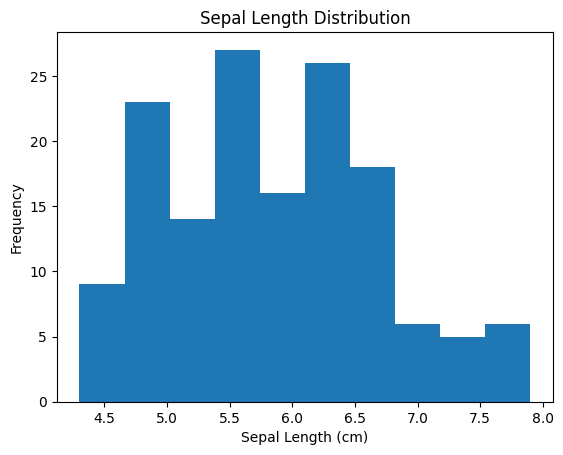

In [40]:
# --- Histogram: distribution of sepal length ---
df['sepal_length'].plot(kind='hist', title='Sepal Length Distribution') # default bins = 10 -> 20 is often better for larger datasets
plt.xlabel('Sepal Length (cm)')
plt.show()

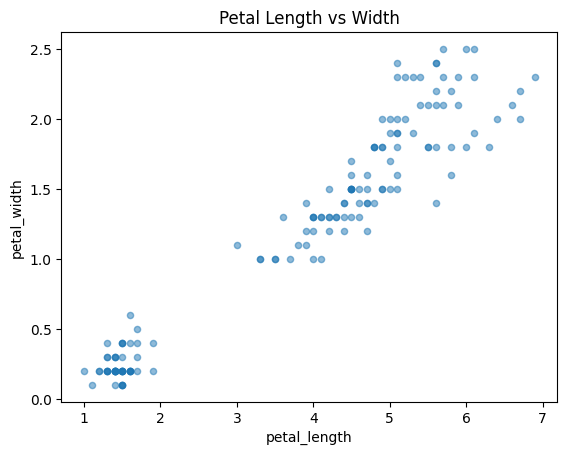

In [46]:
# --- Scatter plot: petal length vs petal width ---
# alpha controls transparency so overlapping points are visible
df.plot(
    kind='scatter',
    x='petal_length',
    y='petal_width',
    alpha=0.5,
    title='Petal Length vs Width'
)
plt.show()

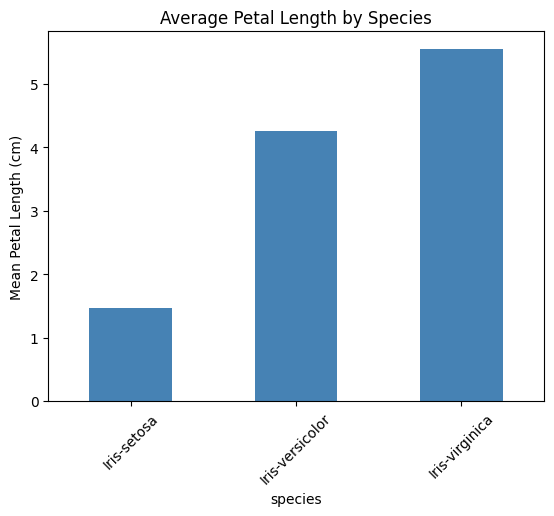

In [48]:
# --- Bar chart: mean petal length per species ---
# Chain groupby → mean → plot for a one-liner insight
df.groupby('species')['petal_length'].mean().plot(
    kind='bar',
    title='Average Petal Length by Species',
    color='steelblue'
)
plt.ylabel('Mean Petal Length (cm)')
plt.xticks(rotation=45)
plt.show()

---
## Part 7: NumPy — Fast Numerical Arrays

### Why NumPy?

A Python list is flexible but slow for maths. A **NumPy array** stores all values as the same type in contiguous memory — this makes it **10–100x faster** for numerical operations.

NumPy is also the foundation that Pandas is built on — every column in a DataFrame is a NumPy array underneath.

### Key Concepts

- **Array:** a grid of numbers, all the same type

- **Vectorisation:** applying an operation to every element at once — no loop needed

- **Broadcasting:** applying an operation between arrays of different (but compatible) shapes

> **Discussion:** Can you think of a scenario where speed matters when processing numbers? (e.g., images, simulations, real-time data)

In [50]:
# --- Speed demo: NumPy vs Python list ---
python_list = list(range(1_000_000))
numpy_array = np.arange(1_000_000)

# %timeit measures how long a line takes to run (run multiple times for accuracy)
%timeit sum(python_list)
%timeit np.sum(numpy_array)

2.06 ms ± 9.82 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
71.7 μs ± 447 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [92]:
# --- Creating arrays ---

# From a Python list
arr = np.array([10, 20, 30, 40, 50, 60])

# --- A range of numbers ---
range_arr = np.arange(0, 10, 2)          # (start, stop, step): [0, 2, 4, 6, 8]

lin_arr = np.linspace(0, 1, 5)           # 5 numbers evenly spaced between 0 and 1: [0. , 0.25, 0.5 , 0.75, 1.]

log_arr = np.logspace(0, 3, 4)           # 4 numbers evenly spaced on a log scale from 10^0 to 10^3: [   1.   10.  100. 1000.]

zero_arr = np.zeros((3, 3))              # 3 rows, 3 columns of zeros

# --- A 2D array (like a matrix) ---
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

print('1D array     :', arr)
print('Range arr    :', range_arr)
print('Linspace arr :', lin_arr)
print('Logspace arr :', log_arr)
print('Matrix shape :', matrix.shape)
print(matrix)
print('---')
print(zero_arr)

1D array     : [10 20 30 40 50 60]
Range arr    : [0 2 4 6 8]
Linspace arr : [0.   0.25 0.5  0.75 1.  ]
Logspace arr : [   1.   10.  100. 1000.]
Matrix shape : (3, 3)
[[1 2 3]
 [4 5 6]
 [7 8 9]]
---
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [77]:
# --- Vectorised arithmetic: no loop needed ---
prices = np.array([100, 200, 150, 300, 250])

# Apply a 10% discount to every price at once
discounted = prices * 0.9
print('Original :', prices)
print('Discounted:', discounted)

Original : [100 200 150 300 250]
Discounted: [ 90. 180. 135. 270. 225.]


In [83]:
# --- Indexing and slicing a 2D array ---
# Syntax: matrix[row, column]  — use : to mean 'all'
print("-matrix-")
print(matrix)
print('Element at row 0, col 2 :', matrix[0, 2])   # → 3
print('Entire first row        :', matrix[0, :])   # → [1 2 3]
print('Entire second column    :', matrix[:, 1])   # → [2 5 8]

-matrix-
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Element at row 0, col 2 : 3
Entire first row        : [1 2 3]
Entire second column    : [2 5 8]


In [95]:
# --- Reshaping arrays ---
# Change a 1D array of 6 elements into a 2D array with 2 rows and 3 columns
print(arr)
reshaped = arr.reshape(2, 3)
reshaped_2 = arr.reshape(3, 2)  # Reshape to 3 rows and 2 columns
print('Reshaped array:')
print(reshaped)
print(reshaped_2)

[10 20 30 40 50 60]
Reshaped array:
[[10 20 30]
 [40 50 60]]
[[10 20]
 [30 40]
 [50 60]]


In [85]:
# --- Aggregations with the axis parameter ---
# axis=0 collapses ROWS → gives one result per COLUMN
# axis=1 collapses COLUMNS → gives one result per ROW

print('Column sums(axis=0):', matrix.sum(axis=0))  # [12 15 18]
print('Row sums   (axis=1):', matrix.sum(axis=1))  # [6 15 24]
print('Overall mean       :', matrix.mean())       # 5.0

Column sums(axis=0): [12 15 18]
Row sums   (axis=1): [ 6 15 24]
Overall mean       : 5.0


In [90]:
# --- np.where: find elements matching a condition ---
# Returns the indices where the condition is True
scores = np.array([45, 72, 88, 35, 91, 60])
passing_indices = np.where(scores >= 60)

print('Passing indices:', passing_indices)
print('Passing scores :', scores[passing_indices])

Passing indices: (array([1, 2, 4, 5]),)
Passing scores : [72 88 91 60]


---
## Part 8: Datetime Handling

Dates and times are stored as plain text in CSV files. Pandas can convert them to proper **datetime objects**, which unlocks powerful time-based operations.

### Workflow

1. Load the CSV — dates arrive as strings

2. Convert with `pd.to_datetime()`

3. Extract components using the **`.dt` accessor** (`.dt.year`, `.dt.month`, `.dt.day`, `.dt.weekday`)

4. Use date arithmetic (add/subtract days, calculate durations)

**Discussion:** What new analysis questions become possible once you can extract the month or day-of-week from a date column?

In [ ]:
# --- Load the Seattle weather dataset (has a date column) ---
weather = pd.read_csv('data/seattle-weather.csv')
print('date column type before conversion:', weather['date'].dtype)
weather.head(3)

date column type BEFORE conversion: str


,date,precipitation,temp_max,temp_min,wind,weather
0,2012/01/01,0.0,12.8,5.0,4.7,drizzle
1,2012/01/02,10.9,10.6,2.8,4.5,rain
2,2012/01/03,0.8,11.7,7.2,2.3,rain


In [99]:
# --- Convert the 'date' column from string to datetime ---
weather['date'] = pd.to_datetime(weather['date'])
print('date column type after conversion:', weather['date'].dtype)
weather.head(3)

date column type after conversion: datetime64[us]


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain


In [ ]:
# --- Extract date components using the .dt accessor ---
weather['year'] = weather['date'].dt.year

weather['month'] = weather['date'].dt.month # 1 = January, obviously.

weather['weekday'] = weather['date'].dt.weekday  # 0 = Monday, 6 = Sunday

weather[['date', 'year', 'month', 'weekday']].head(5)

,date,year,month,weekday
0,2012-01-01,2012,1,6
1,2012-01-02,2012,1,0
2,2012-01-03,2012,1,1
3,2012-01-04,2012,1,2
4,2012-01-05,2012,1,3


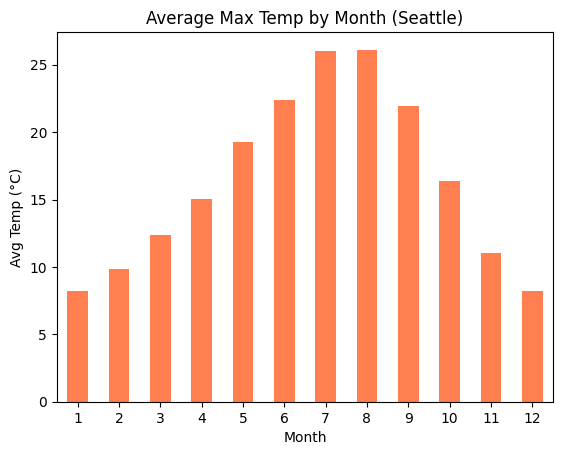

In [113]:
# --- Practical insight: average temperature by month ---

max_temp = weather.groupby('month')['temp_max'].mean()
max_temp.plot(
    kind='bar', 
    title='Average Max Temp by Month (Seattle)', 
    color='coral')

"""min_temp = weather.groupby('month')['temp_min'].mean()
min_temp.plot(
    kind='bar', 
    title='Average Max/Min Temp by Month (Seattle)',
    color='lightblue')"""

plt.xlabel('Month')
plt.ylabel('Avg Temp (°C)')
# plt.legend(['Max Temp', 'Min Temp'])
plt.xticks(rotation=0)
plt.show()

---
## Part 9: Combining DataFrames

Real data is rarely in one table. You will often need to combine datasets.

### Three main methods

| Method | What it does |
|---|---|
| `pd.concat([df1, df2], axis=0)` | Stack rows on top of each other |
| `pd.concat([df1, df2], axis=1)` | Place columns side by side |
| `pd.merge(left, right, on='key', how='inner')` | Join on a shared column (like SQL) |

### Join types for `pd.merge()`

- **`inner`** — only rows that match in **both** tables
- **`left`** — all rows from the left, matching rows from the right
- **`outer`** — all rows from both tables (fills NaN where no match)

**Discussion:** Imagine you have a customer table and an orders table. Which join type would you use to find all customers, even those who haven't ordered yet?

In [114]:
# --- Demonstrate pd.concat: stack two small DataFrames vertically ---
batch_1 = pd.DataFrame({'name': ['Alice', 'Bob'],   'score': [85, 92]})
batch_2 = pd.DataFrame({'name': ['Carol', 'Dan'],   'score': [78, 88]})
print('Batch 1:')
print(batch_1)
print('\nBatch 2:')
print(batch_2)

Batch 1:
    name  score
0  Alice     85
1    Bob     92

Batch 2:
    name  score
0  Carol     78
1    Dan     88


In [119]:
# Combine into one table, sort the scores and reset the index
all_students = pd.concat([batch_1, batch_2], axis=0).sort_values("score", ascending=False).reset_index(drop=True)
print('Combined:')
print(all_students)

Combined:
    name  score
0    Bob     92
1    Dan     88
2  Alice     85
3  Carol     78


In [120]:
# --- Demonstrate pd.merge: join two tables on a shared column ---
students  = pd.DataFrame({'id': [1, 2, 3, 4],        'name': ['Alice', 'Bob', 'Carol', 'Dan']})
grades    = pd.DataFrame({'id': [1, 2, 3],            'grade': ['A', 'B', 'A']})

# --- inner join: only students who have a grade ---
inner_result = pd.merge(students, grades, on='id', how='inner')
print('Inner join (only matched rows):')
print(inner_result)

# --- left join: all students, NaN if no grade ---
left_result = pd.merge(students, grades, on='id', how='left')
print('\nLeft join (all students):')
print(left_result)

Inner join (only matched rows):
   id   name grade
0   1  Alice     A
1   2    Bob     B
2   3  Carol     A

Left join (all students):
   id   name grade
0   1  Alice     A
1   2    Bob     B
2   3  Carol     A
3   4    Dan   NaN


In [122]:
# --- Real example: load and merge red + white wine datasets ---
red_wine   = pd.read_csv('data/winequality-red.csv',   sep=';')
white_wine = pd.read_csv('data/winequality-white.csv', sep=';')
red_wine.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


In [123]:
white_wine.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6


In [128]:
# Add a label column before combining
red_wine['type']   = 'red'
white_wine['type'] = 'white'

# Stack both datasets into one
wine = pd.concat([red_wine, white_wine], axis=0).reset_index(drop=True)

print('Combined wine dataset shape:', wine.shape)
print(wine['type'].value_counts())
wine.head()

Combined wine dataset shape: (6497, 13)
type
white    4898
red      1599
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


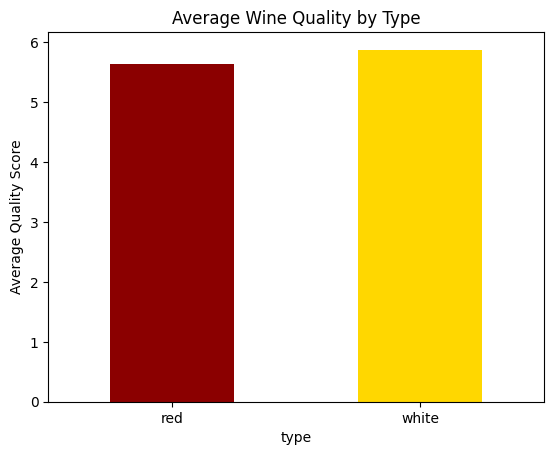

In [129]:
# --- Compare average quality between red and white wine ---
wine.groupby('type')['quality'].mean().plot(
    kind='bar',
    title='Average Wine Quality by Type',
    color=['darkred', 'gold']
)
plt.ylabel('Average Quality Score')
plt.xticks(rotation=0)
plt.show()

---

## Key Takeaways

Here is what you covered in this session:

**Pandas**

- Load data with `pd.read_csv()` and explore with `.head()`, `.info()`, `.describe()`

- Select columns with `[]`, rows by position with `.iloc[]`, rows by condition with `.loc[]`

- Filter with boolean masks — wrap each condition in `()`

- Aggregate with `.groupby()` → one of the most used patterns in data science

- Create new columns with direct arithmetic on existing columns

- Handle missing values with `.fillna()` and `.dropna()`

- Plot directly with `.plot(kind='hist'/'bar'/'scatter'/'box')`

**NumPy**

- Arrays are faster than lists for numerical work

- No loops needed — operations apply element-wise automatically

- Use `axis=0` for column-wise, `axis=1` for row-wise aggregations

- `np.where()` finds indices matching a condition

**Datetime**

- Convert string columns with `pd.to_datetime()`

- Extract year, month, day, weekday using the `.dt` accessor

**Combining Data**

- Stack rows with `pd.concat(axis=0)`

- Join on a key column with `pd.merge()` — choose join type carefully

---

## Check Your Understanding

1. What is the difference between a **Series** and a **DataFrame**?

2. You want rows where `quality > 7` AND `alcohol < 12`. How could you write that filter?

3. What does `.groupby('species').mean()` actually do — in plain English?

4. If `axis=0` means "down the rows", what does `matrix.sum(axis=0)` produce for a 3×4 matrix?

5. You have a `date` column stored as strings. What two steps do you take before you can extract the month?
